# 8j — Preliminary composable forecast (four ways)

Implements `inst/1a_preliminary_framework_plan.md` + the fixes/extensions in `inst/1c`,
`inst/1d`, `inst/1e`: a joint renewal / next-generation-matrix model driven by **age-pair
contact-degree distributions**, scored **four ways** — the 2×2 grid of {unweighted
**NegBin**, weighted **Hurdle-Weibull**} degree models × {**Mean**, **Neighbourhood**} NGM.

The contact **mean** is estimated with **structural reciprocity** (`log μ_{i→j} = r + log Nⱼ`)
and **spatial-GP smoothing** across the age-pair grid (separable RBF, shared length-scale;
inst/1e). Forecasts use the **contact-updated iterate** over **4 origins** × 4 horizons;
**WIS** is computed on a **log scale** and aggregated **by horizon** via R `scoringutils`.

Fitting uses **Pathfinder.jl** (parsimonious fit / init) and optionally **Turing NUTS** (`USE_NUTS`).
See the specs for modelling details and the remaining lean simplifications (constant
within-window contacts; reduced transmission block).

In [1]:
ENV["GKSwstype"] = "100"   # headless GR (off-screen PNG) for nbconvert
include("forecast_utils.jl")   # single preamble: base + CoMix pipeline + forecasting framework
using Random, Statistics
mkpath("../res")

USE_NUTS = false   # true ⇒ formal Turing NUTS fit (slow); false ⇒ Pathfinder parsimonious fit

false

## §1 Window, infection/antibody data, and age-pair degree data

In [2]:
cfg  = FrameworkConfig()
grid = cis_age_grid()

# Read the CoMix contact data ONCE and reuse it across every window (avoids re-reading/
# re-joining the full Arrow per origin×horizon). Then roll the forecast origin over the
# whole period the current datasets support ("available period"): each origin needs a
# 12-week fit/lag window back to the first inc2prev week, and contact data out to
# origin+3 for the contact-updated iterate. `available_forecast_origins` derives the range.
raw  = load_raw_contact_inputs()
FORECAST_ORIGINS = available_forecast_origins(cfg; grid = grid, craw = raw.craw)
wins = [WeeklyWindow(o; n_fit = cfg.n_fit, smax = cfg.smax, horizons = cfg.horizons)
        for o in FORECAST_ORIGINS]

println("contact data span  : ", extrema(skipmissing(raw.craw.date)))
println("forecast origins   : ", length(wins), " weekly, ",
        first(FORECAST_ORIGINS), " … ", last(FORECAST_ORIGINS))
let w = wins[1], wd0 = load_window_data(wins[1]; grid = grid)
    println("origin[1] fit weeks: ", w.fit_weeks[1], " … ", w.fit_weeks[end])
    println("weekly infections @ origin[1] (age): ", round.(wd0.I_mean[:, end]; digits = 0))
end

contact data span  : (

Date("

2020-03-23"), Date("2021-06-23"))
forecast origins   : 33 weekly, 2020-10-18 … 2021-05-30


origin[1] fit weeks: 2020-08-30

 … 2020-10-18
weekly infections @ origin[1] (age): 

[99876.0, 64778.0, 116703.0, 89814.0, 124356.0, 117410.0, 41714.0]


In [3]:
# Fit config: the four combos and the parallel-fit concurrency (CPU- and memory-balanced).
combos = [(dm, nb) for dm in (NegBinAgePair(), HurdleWeibullAgePair())
                    for nb in (MeanNGM(), NeighbourhoodDegreeNGM())]
MAX_FIT_CONCURRENCY = fit_concurrency()          # min(threads, cores−1, RAM-budget)
if Threads.nthreads() == 1
    @warn "Julia has 1 thread — pre-fit runs sequentially. Start with JULIA_NUM_THREADS>1 " *
          "(e.g. $(max(1, Sys.CPU_THREADS - 1))) for parallel fitting."
end
println("combos = ", length(combos), " | fit concurrency = ", MAX_FIT_CONCURRENCY,
        " | total fits = ", length(wins) * length(combos) * length(cfg.horizons),
        " (cached ones are skipped)")

combos = 4

 | fit concurrency = 9 | total fits = 528 (cached ones are skipped)


## §2 Roll over the available period — fit four ways, forecast 1–4 weeks ahead

For **each weekly origin** across the available period the four combos are fit and forecast.
The contact **mean** is a **reciprocity-structural, GP-smoothed** field (one symmetric
log-rate per unordered age pair, separable-RBF smoothing over age midpoints 70+→74.5,
`log μ_{i→j}=r+log Nⱼ` ⟹ exact reciprocity). Forecasting is the **contact-updated iterate**
(inst/1d): per origin t₀ and horizon `h`, the degree window ends at `t₀+h−1` (infections/
antibody frozen at t₀), the NGM is refreshed and one renewal step taken.

The loop is **memory-bounded**: per origin it builds only that origin's 4 degree windows
(reusing the single raw read), **parallel-pre-fits** its 16 chains (`prefit_chains!`, bounded
to `MAX_FIT_CONCURRENCY` simultaneous fits), assembles the forecasts, then discards the degree
data. Chains are cached per (origin, horizon) under `../dt_intermediate/8j_chn_*.jld2`, so the
run is **resumable** — a re-run reloads finished chains and only fits what's missing.

In [4]:
qtabs     = DataFrame[]
fc_store  = Dict{Tuple{Date,String},Array{Float64,3}}()
crps_rows = NamedTuple[]
skipped   = Tuple{Date,String}[]
t0 = time()
for (oi, win_o) in enumerate(wins)
    wd_o    = load_window_data(win_o; grid = grid)
    truth_o = load_forecast_truth(win_o; grid = grid)
    # this origin's 4 contact/degree windows (reuse the single raw read); discarded after.
    apd_o = [prepare_degree_data(
                 WeeklyWindow(win_o.origin + Day(7 * (h - 1));
                              n_fit = cfg.n_fit, smax = cfg.smax, horizons = cfg.horizons),
                 cfg; grid = grid, setting = :all,
                 df_part_raw = raw.df_part, craw_raw = raw.craw)
             for h in cfg.horizons]
    # parallel pre-fit this origin's 16 chains (cached ones skipped)
    prefit_chains!(combos, [win_o], [wd_o], cfg, [apd_o];
                   grid = grid, setting = :all, use_nuts = USE_NUTS,
                   save_dir = "../dt_intermediate", max_concurrent = MAX_FIT_CONCURRENCY)
    for (dm, nb) in combos
        lbl = string(degree_label(dm), "|", ngm_label(nb))
        try   # keep the multi-origin run alive if a single origin×combo fit is pathological
            fc = iterated_forecast(dm, nb, wd_o, cfg, win_o;
                                   grid = grid, setting = :all, use_nuts = USE_NUTS,
                                   save_dir = "../dt_intermediate", apd_by_h = apd_o)
            fc_store[(win_o.origin, lbl)] = fc
            push!(qtabs, to_quantile_long(fc, truth_o, lbl, win_o, cfg, grid.LAB))
            push!(crps_rows, (origin = win_o.origin, model = lbl, mean_crps = mean_crps(fc, truth_o)))
        catch err
            push!(skipped, (win_o.origin, lbl))
            @warn "skipped origin×combo" origin=win_o.origin model=lbl exception=err
        end
    end
    if oi % 5 == 0 || oi == length(wins)
        println("  origin $oi/$(length(wins)) (", win_o.origin, ")  elapsed ",
                round(Int, time() - t0), "s")
    end
end
qall = vcat(qtabs...)              # all origins × combos, tagged by forecast_date=origin
println("quantile rows: ", size(qall), "   (", length(wins), " origins × ", length(combos),
        " combos; skipped ", length(skipped), ")")
size(qall)

[ Info: prefit_chains!: fitting 16/16 chains; concurrency=9 (threads=12, cores=10, mem_avail=18.5 GiB)


┌ Warning: 1 (0.1%) updates to the inverse Hessian estimate were rejected to keep it positive definite.
└ @ Pathfinder ~/.julia/packages/Pathfinder/1qXKy/src/singlepath.jl:225


┌ Warning: 1 (0.1%) updates to the inverse Hessian estimate were rejected to keep it positive definite.
└ @ Pathfinder ~/.julia/packages/Pathfinder/1qXKy/src/singlepath.jl:225


┌ Warning: 4 (0.4%) updates to the inverse Hessian estimate were rejected to keep it positive definite.
└ @ Pathfinder ~/.julia/packages/Pathfinder/1qXKy/src/singlepath.jl:225
┌ Warning: 2 (0.2%) updates to the inverse Hessian estimate were rejected to keep it positive definite.
└ @ Pathfinder ~/.julia/packages/Pathfinder/1qXKy/src/singlepath.jl:225


┌ Warning: 4 (0.4%) updates to the inverse Hessian estimate were rejected to keep it positive definite.
└ @ Pathfinder ~/.julia/packages/Pathfinder/1qXKy/src/singlepath.jl:225


...

┌ Warning: 4 (0.4%) updates to the inverse Hessian estimate were rejected to keep it positive definite.
└ @ Pathfinder ~/.julia/packages/Pathfinder/1qXKy/src/singlepath.jl:225


  origin 33/33 (2021-05-30

)  elapsed 5531s
quantile rows: (

70224, 8)   (33 origins × 4 combos; skipped 0)


(70224, 8)

## §3 Score four ways — WIS via `scoringutils`

In [5]:
scores = score_wis(qall)   # scores both natural & log scale; aggregated by horizon (inst/1e)

# Headline: LOG-SCALE WIS aggregated BY HORIZON across all origins.
by_mh_log = sort(@subset(scores.by_model_h, :scale .== "log"), [:model, :horizon])
by_m_log  = sort(@subset(scores.by_model,   :scale .== "log"), :wis)

println("\n===== log-scale WIS by model (aggregated over horizons & ", length(wins), " origins) =====")
show(by_m_log, allcols = true); println()
println("\n===== log-scale WIS by model × horizon (aggregated over origins) =====")
show(by_mh_log, allcols = true); println()

# native sample-CRPS cross-check, averaged over origins
crps_df = sort(combine(groupby(DataFrame(crps_rows), :model), :mean_crps => mean => :mean_crps),
               :mean_crps)
println("\nmean native CRPS (avg over origins):")
show(crps_df, allrows = true); println()

CSV.write("../res/8j_scores_by_model.csv", scores.by_model)            # both scales
CSV.write("../res/8j_scores_by_model_horizon.csv", scores.by_model_h)  # both scales × horizon
CSV.write("../res/8j_scores_by_model_date.csv", scores.by_model_dt)    # both scales × origin
by_mh_log


===== log-scale WIS by model (aggregated over horizons & 33

 origins) =====
4×10 DataFrame
 Row │ model                            scale   wis       overprediction  underprediction  dispersion  bias        interval_coverage_50  interval_coverage_90  ae_median 
     │ String                           String  Float64   Float64         Float64          Float64     Float64     Float64               Float64               Float64   
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ unweighted-negbin|mean           log     0.353958        0.128697         0.184038   0.0412225  -0.0145022              0.232684              0.47619    0.411907
   2 │ weighted-hweibull|mean           log     0.378183        0.115874         0.220181   0.0421286  -0.0888528              0.192641              0.435065   0.439078
   3 │ weighted-hweibull|neighbourhood  log     0.396217        0.112397         0.23619    0.0476294  -0.115368         


===== log-scale WIS by model × horizon (aggregated over origins) =====
16×11 DataFrame
 Row │ model                            horizon  scale   wis       overprediction  underprediction  dispersion  bias        interval_coverage_50  interval_coverage_90  ae_median 
     │ String                           Int64    String  Float64   Float64         Float64          Float64     Float64     Float64               Float64               Float64   
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ unweighted-negbin|mean                 1  log     0.20921        0.0728632        0.0941605   0.0421862   0.0316017              0.320346              0.683983   0.262007
   2 │ unweighted-negbin|mean                 2  log     0.307078       0.11214          0.154819    0.0401193   0.0012987              0.246753              0.506494   0.362344
   3 │ unweighted-n


mean native CRPS (avg over origins):
4×2 DataFrame
 Row │ model                            mean_crps 
     │ String                           Float64   
─────┼────────────────────────────────────────────
   1 │ unweighted-negbin|mean             17423.5
   2 │ weighted-hweibull|mean             17983.2
   3 │ weighted-hweibull|neighbourhood    19195.4
   4 │ unweighted-negbin|neighbourhood    19242.7


Row,model,horizon,scale,wis,overprediction,underprediction,dispersion,bias,interval_coverage_50,interval_coverage_90,ae_median
,String,Int64,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,unweighted-negbin|mean,1,log,0.20921,0.0728632,0.0941605,0.0421862,0.0316017,0.320346,0.683983,0.262007
2,unweighted-negbin|mean,2,log,0.307078,0.11214,0.154819,0.0401193,0.0012987,0.246753,0.506494,0.362344
3,unweighted-negbin|mean,3,log,0.404939,0.151852,0.213417,0.0396701,-0.0294372,0.190476,0.398268,0.463448
4,unweighted-negbin|mean,4,log,0.494604,0.177934,0.273756,0.0429142,-0.0614719,0.17316,0.316017,0.559829
5,unweighted-negbin|neighbourhood,1,log,0.359775,0.0857798,0.224112,0.0498837,-0.0627706,0.255411,0.606061,0.424776
6,unweighted-negbin|neighbourhood,2,log,0.340734,0.101998,0.193551,0.0451851,-0.137229,0.199134,0.493506,0.404364
7,unweighted-negbin|neighbourhood,3,log,0.41854,0.116709,0.25562,0.0462109,-0.154978,0.181818,0.411255,0.483982
8,unweighted-negbin|neighbourhood,4,log,0.498832,0.141057,0.31054,0.0472361,-0.188745,0.155844,0.311688,0.571029
9,weighted-hweibull|mean,1,log,0.221067,0.0703246,0.107708,0.0430345,0.0004329,0.294372,0.632035,0.273812


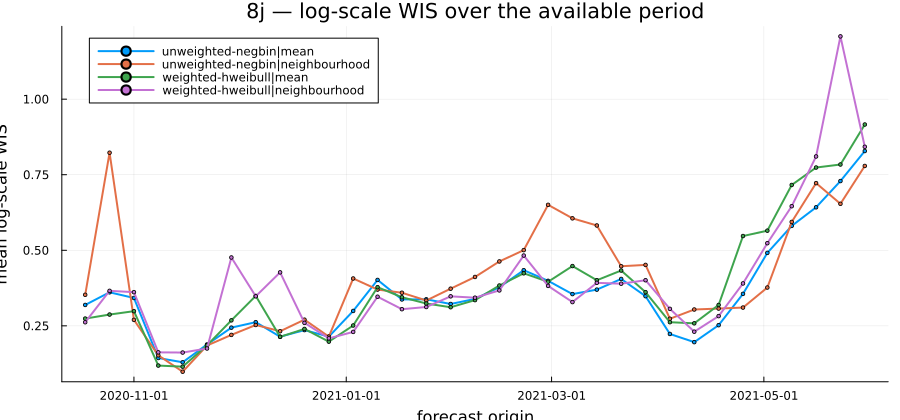

In [6]:
# log-scale WIS by horizon (one line per model), aggregated over all origins
Hn = length(cfg.horizons)
wis_h_fig = plot(; xlabel = "horizon (weeks)", ylabel = "mean log-scale WIS",
                 title = "8j — log-scale WIS by horizon ($(length(wins)) origins)",
                 size = (760, 420), legend = :topleft, xticks = 1:Hn)
for m in unique(by_mh_log.model)
    sub = sort(@subset(by_mh_log, :model .== m), :horizon)
    plot!(wis_h_fig, sub.horizon, sub.wis; marker = :circle, lw = 2, label = m)
end
savefig(wis_h_fig, "../res/8j_wis_by_horizon.png")

# aggregated four-ways bar (log scale)
wis_bar = bar(by_m_log.model, by_m_log.wis; orientation = :h, legend = false,
              xlabel = "mean log-scale WIS (lower = better)",
              title = "8j — log-scale WIS four ways (aggregated)",
              size = (760, 360), left_margin = 8Plots.mm)
savefig(wis_bar, "../res/8j_wis_four_ways.png")

# log-scale WIS over the forecast period (one line per model) — the full-period skill
by_dt_log = sort(@subset(scores.by_model_dt, :scale .== "log"), [:model, :forecast_date])
wis_t_fig = plot(; xlabel = "forecast origin", ylabel = "mean log-scale WIS",
                 title = "8j — log-scale WIS over the available period",
                 size = (900, 420), legend = :topleft)
for m in unique(by_dt_log.model)
    sub = @subset(by_dt_log, :model .== m)
    plot!(wis_t_fig, sub.forecast_date, sub.wis; lw = 2, marker = :circle, ms = 2, label = m)
end
savefig(wis_t_fig, "../res/8j_wis_over_time.png")
wis_t_fig

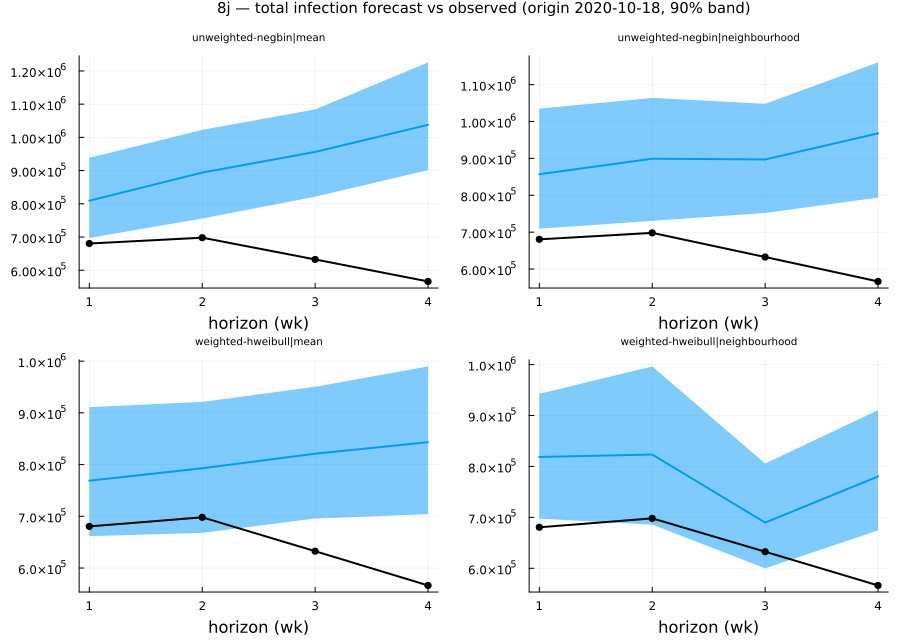

In [7]:
# Forecast fan (total infections across ages) vs realized — representative origin
origin_show = FORECAST_ORIGINS[1]
truth_show  = load_forecast_truth(wins[1]; grid = grid)
qs_lo, qs_hi = 0.05, 0.95
H = length(cfg.horizons)
panels = Plots.Plot[]
for (dm, nb) in combos
    lbl = string(degree_label(dm), "|", ngm_label(nb))
    fc  = fc_store[(origin_show, lbl)]
    tot = dropdims(sum(fc; dims = 1); dims = 1)          # H × draws
    med = [median(tot[h, :]) for h in 1:H]
    lo  = [quantile(tot[h, :], qs_lo) for h in 1:H]
    hi  = [quantile(tot[h, :], qs_hi) for h in 1:H]
    tr  = [sum(truth_show[:, h]) for h in 1:H]
    p = plot(1:H, med; ribbon = (med .- lo, hi .- med), lw = 2, label = "forecast",
             title = lbl, titlefontsize = 7, xlabel = "horizon (wk)", legend = false)
    plot!(p, 1:H, tr; lw = 2, color = :black, marker = :circle, label = "observed")
    push!(panels, p)
end
fan = plot(panels...; layout = (2, 2), size = (900, 640),
           plot_title = "8j — total infection forecast vs observed (origin $origin_show, 90% band)",
           plot_titlefontsize = 10)
savefig(fan, "../res/8j_forecast_fan.png")
fan

## §4 Notes

- **Available period**: the forecast origin is rolled weekly over the full span the current
  datasets support — bounded below by the first inc2prev week (the 12-week fit window) and
  above by the CoMix contact-data end (the iterate needs contacts to origin+3). Scores are
  written per model, per model×horizon, and per model×origin (`res/8j_scores_by_model*.csv`).
- **Four ways** = the 2×2 grid; the headline metric is **log-scale WIS aggregated by horizon**
  across all origins (`res/8j_scores_by_model_horizon.csv`, `scale=="log"`), with
  over/under-prediction & dispersion components, bias, and 50/90% coverage.
- **Parallel, resumable fitting**: per origin the 16 chains are pre-fit concurrently
  (`prefit_chains!`, bounded to a CPU/RAM-balanced `fit_concurrency()`), then reloaded to
  assemble forecasts; chains are cached per (origin, horizon), so a re-run only fits what's
  missing. The raw CoMix tables are read once and reused across every window.
- **Reciprocity + GP smoothing of the mean** (inst/1e): the contact mean is a *symmetric*
  log-rate over the 28 unordered age pairs, `log μ_{i→j} = r_{min,max} + log(popⱼ)` (so
  `popᵢ·μ_{i→j} = popⱼ·μ_{j→i}` exactly), `r` a **separable-RBF GP** over age midpoints
  (70+ → 74.5; shared ρ; non-centred `f = η·L·z`). The neighbourhood NGM stays
  reciprocity-balanced (size-biased C0 is not reciprocal even when μ is).
- **Group-contact duration weight** (inst/1e): `:cnt_mass=="mass"` contacts (no recorded
  duration) get `cfg.w_dur_group = 2.5/240` (fixed now, estimable later); counts unchanged.
- **Neighbourhood-degree NGM among non-zero** (inst/1c, 1d): `C0 = ⟨k²⟩/⟨k⟩ × g`,
  `g = 1/(1−P₀)` (NegBin, floored) / `g = (1−p⁰)` (hurdle-Weibull). Mean NGM (`C0 = ⟨k⟩`) unchanged.
- **Contact-updated iterate** (inst/1d): infections/antibody frozen at each origin; the contact
  matrix is re-estimated each horizon (window ending origin+h−1); renewal stepped one week at a
  time (mean-plugged lags).
- **WIS on a log scale** (inst/1e): `transform_forecasts(fun=log_shift, offset=1)`; both scales
  written, log is the headline. Run uses **Pathfinder** (`USE_NUTS=false`); set `true` for NUTS.
- Remaining lean simplifications: within-window contacts constant per cell (temporal GP is the
  swap-in seam); reference transmission block; 5-day generation interval. Revisit before
  scientific interpretation.